<a href="https://colab.research.google.com/github/jceltruda/Projects-in-AI-and-ML/blob/main/Project_5/ML_AI_Projects_5_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2

## Part 1

In [1]:
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Download dataset
dataset_path = kagglehub.dataset_download("pkdarabi/bone-break-classification-image-dataset")
print("Path to dataset files:", dataset_path)
data_dir = os.path.join(dataset_path, 'Bone Break Classification/Bone Break Classification')

batch_size = 64
image_size = 64

# Transform for VAE
vae_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

# Transform for GAN
gan_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Dataloaders
vae_dataset = datasets.ImageFolder(root=data_dir, transform=vae_transform)
gan_dataset = datasets.ImageFolder(root=data_dir, transform=gan_transform)

vae_loader = DataLoader(vae_dataset, batch_size=batch_size, shuffle=True)
gan_loader = DataLoader(gan_dataset, batch_size=batch_size, shuffle=True)

# Print images
def show_images(images, title="Generated Images", normalize=False):
    plt.figure(figsize=(8, 8))
    plt.axis("off")
    plt.title(title)
    if normalize:
        images = (images + 1) / 2.0
    plt.imshow(np.transpose(torchvision.utils.make_grid(images[:64], padding=2, normalize=False).cpu(), (1, 2, 0)))
    plt.show()

Using device: cpu


100%|██████████| 28.4M/28.4M [00:00<00:00, 153MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/pkdarabi/bone-break-classification-image-dataset/versions/4


In [2]:
# VAE Model
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)

        # Decoder
        self.decoder_input = nn.Linear(latent_dim, 256 * 4 * 4)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_input(z)
        h = h.view(-1, 256, 4, 4)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# VAE Loss function
def vae_loss_function(recon_x, x, mu, logvar):
    MSE = nn.functional.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + KLD

In [4]:
# VAE training
vae_model = VAE(latent_dim=128).to(device)
vae_optimizer = optim.Adam(vae_model.parameters(), lr=1e-3)
vae_epochs = 10

print("Starting training")
for epoch in range(vae_epochs):
    vae_model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(vae_loader):
        data = data.to(device)
        vae_optimizer.zero_grad()

        recon_batch, mu, logvar = vae_model(data)
        loss = vae_loss_function(recon_batch, data, mu, logvar)

        loss.backward()
        train_loss += loss.item()
        vae_optimizer.step()

    avg_loss = train_loss / len(vae_loader.dataset)
    print(f'Epoch {epoch+1}/{vae_epochs}, Average Loss: {avg_loss:.4f}')

Starting training
Epoch [1/10], Average Loss: 927.7294
Epoch [2/10], Average Loss: 544.6793
Epoch [3/10], Average Loss: 424.7704
Epoch [4/10], Average Loss: 391.0640
Epoch [5/10], Average Loss: 365.0753
Epoch [6/10], Average Loss: 304.8663
Epoch [7/10], Average Loss: 269.2119
Epoch [8/10], Average Loss: 248.9852
Epoch [9/10], Average Loss: 239.6014
Epoch [10/10], Average Loss: 230.5981


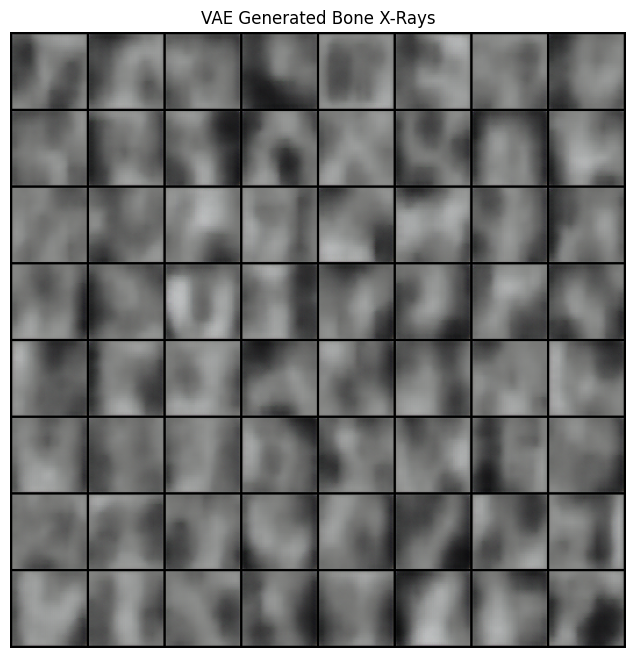

In [5]:
# Generate VAE images
vae_model.eval()
with torch.no_grad():
    # Sample from standard normal distribution
    z = torch.randn(64, 128).to(device)
    vae_generated_images = vae_model.decode(z)
    show_images(vae_generated_images, title="VAE Generated Bone X-Rays", normalize=False)

## Part 2

In [10]:
# Generator
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1, 1).squeeze(1)

# Initialize models
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

netG = Generator(latent_dim=100).to(device)
netG.apply(weights_init)

netD = Discriminator().to(device)
netD.apply(weights_init)

# GAN loss and optimizers
gan_criterion = nn.BCELoss()
optimizerD = optim.Adam(netD.parameters(), lr=0.0001, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [11]:
# GAN training
gan_epochs = 15
latent_dim = 100

# Fixed noise
fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)

print("Starting training")
for epoch in range(gan_epochs):
    for i, (data, _) in enumerate(gan_loader, 0):
        netD.zero_grad()
        real_cpu = data.to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), 1.0, dtype=torch.float, device=device)

        output = netD(real_cpu)
        errD_real = gan_criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(0.0)
        output = netD(fake.detach())
        errD_fake = gan_criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()

        errD = errD_real + errD_fake
        optimizerD.step()

        netG.zero_grad()
        label.fill_(1.0)
        output = netD(fake)
        errG = gan_criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()

    print(f'Epoch {epoch+1}/{gan_epochs}, Loss_D: {errD.item():.4f}, Loss_G: {errG.item():.4f}, D(x): {D_x:.4f}, D(G(z)): {D_G_z1:.4f} / {D_G_z2:.4f}')

Starting training
Epoch 1/15, Loss_D: 0.9987, Loss_G: 7.1254, D(x): 0.7425, D(G(z)): 0.3550 / 0.0013
Epoch 2/15, Loss_D: 0.4644, Loss_G: 8.3138, D(x): 0.8921, D(G(z)): 0.2582 / 0.0003
Epoch 3/15, Loss_D: 0.2144, Loss_G: 8.2224, D(x): 0.9049, D(G(z)): 0.0673 / 0.0004
Epoch 4/15, Loss_D: 0.0446, Loss_G: 9.0300, D(x): 0.9711, D(G(z)): 0.0104 / 0.0001
Epoch 5/15, Loss_D: 0.1048, Loss_G: 8.5573, D(x): 0.9909, D(G(z)): 0.0898 / 0.0002
Epoch 6/15, Loss_D: 0.0490, Loss_G: 7.3813, D(x): 0.9846, D(G(z)): 0.0321 / 0.0007
Epoch 7/15, Loss_D: 0.0783, Loss_G: 8.3588, D(x): 0.9779, D(G(z)): 0.0534 / 0.0003
Epoch 8/15, Loss_D: 0.0542, Loss_G: 7.9101, D(x): 0.9831, D(G(z)): 0.0360 / 0.0004
Epoch 9/15, Loss_D: 0.0500, Loss_G: 7.2079, D(x): 0.9750, D(G(z)): 0.0232 / 0.0008
Epoch 10/15, Loss_D: 0.0646, Loss_G: 7.1284, D(x): 0.9730, D(G(z)): 0.0335 / 0.0009
Epoch 11/15, Loss_D: 0.0227, Loss_G: 6.7687, D(x): 0.9950, D(G(z)): 0.0174 / 0.0012
Epoch 12/15, Loss_D: 0.0237, Loss_G: 7.1150, D(x): 0.9948, D(G(z)):

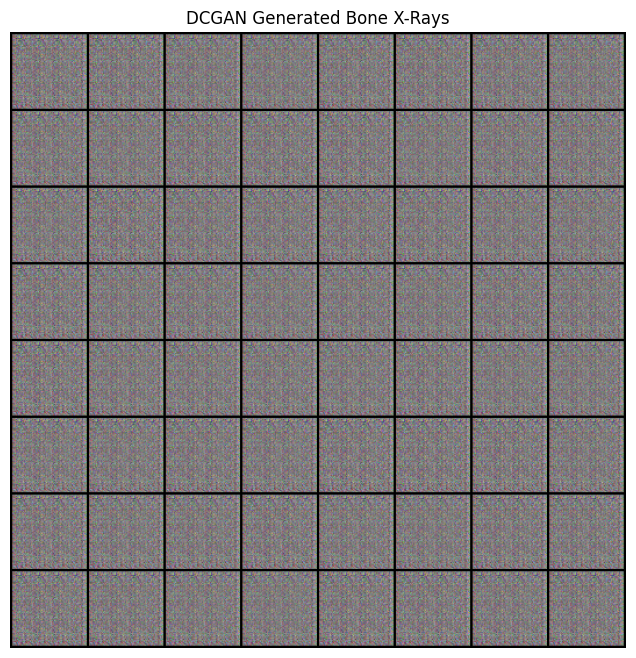

In [12]:
# Generate images using GAN
netG.eval()
with torch.no_grad():
    gan_generated_images = netG(fixed_noise).detach().cpu()
    show_images(gan_generated_images, title="DCGAN Generated Bone X-Rays", normalize=True)

Two models I investigated for generating synthetic bone X-rays are the Variational Autoencoder (VAE) and the Deep Convolutional GAN (DCGAN). Both models were too simple and not trained enough to capture the complexity of this dataset. With more parameters and more compute, the models would have seen more success recreating these images.